In [2]:
import os
import numpy as np
import pandas as pd

DATA_CLEAN_DIR = '../data/10_cleaned'
clean_path = os.path.join(DATA_CLEAN_DIR, 'datania_households_clean.csv')

# Typed checkpoint from 2.2.2 — income is numeric, dates parsed, category typos fixed
df = pd.read_csv(clean_path, dtype={'hh_id': str, 'region_code': str})

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
print('Loaded typed checkpoint:', df.shape)
df.head()

Loaded typed checkpoint: (28, 11)


,hh_id,region_code,province_name,district,urban_rural,hh_size,income_dkw,survey_date,pop_density,education_code,age
0,HH0001,01,Eastern Province,Kurtosis Bay,Urban,4,"45,000.00",2025-01-10,780,3,42
1,HH0002,02,Northern Province,Vector Hills,Rural,6,"32,000.00",2025-01-11,120,2,39
2,HH0003,03,Central Province,Polaris District,Urban,3,"54,000.00",2025-01-12,640,4,33
3,HH0004,04,Southern Province,Lagoon Point,Rural,5,NaN,2025-01-13,80,1,51
4,HH0005,05,Western Province,Gamma Plains,Urban,2,NaN,2025-01-13,520,2,28


## Task 1 group by province_name and calculate the 
1. **sum** and **mean** of income
2. Make a boxplot on income_dkw by province_name and anotherwith the aggregation by mean

In [20]:
import matplotlib.pyplot as plt
agg_df =df.groupby('province_name')['income_dkw'].agg(average='mean', total_sum='sum')
agg_df = agg_df#.reset_index()

In [27]:
agg_df.reset_index()

,province_name,average,total_sum
0,Central Province,"435,000.00","1,305,000.00"
1,Eastern Province,"71,250.00","285,000.00"
2,Highland Province,"63,600.00","318,000.00"
3,Northern Province,"45,750.00","183,000.00"
4,Southern Province,"520,499.50","1,040,999.00"
5,Western Province,"41,800.00","209,000.00"


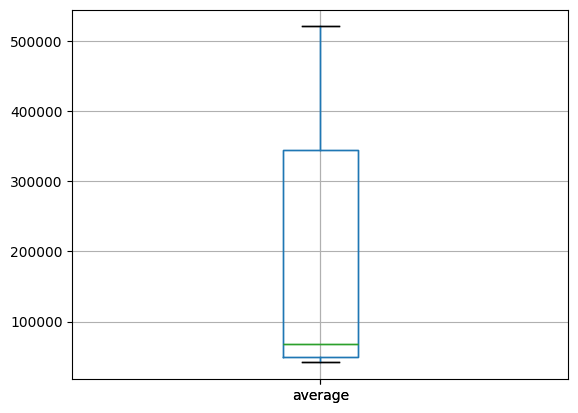

In [19]:
agg_df.boxplot(column='average')
plt.show()

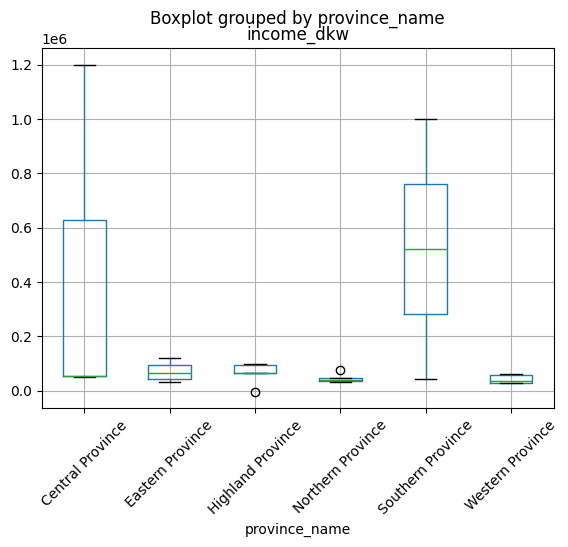

In [13]:
df.boxplot(column='income_dkw', by='province_name', rot=45)
plt.show()

## Task 2 group by province_name and urban_rural and calculate for 
 1. **hh_size** the **sum**, the **mean** and the **median**,
 2. **income_dkw** the **mean** and **std**


In [43]:
df.groupby(['province_name','urban_rural']).agg({
    "hh_size": ['sum', 'mean', 'median'],
    "income_dkw": ['mean', 'std']

})

hh_size              income_dkw           
                                  sum  mean median       mean        std
province_name     urban_rural                                           
Central Province  Rural             9  4.50   4.50  51,000.00        NaN
                  Urban            11  5.50   5.50 627,000.00 810,344.37
Eastern Province  Rural           102 51.00  51.00  60,000.00  38,183.77
                  Urban             5  2.50   2.50  82,500.00  53,033.01
Highland Province Rural             7  7.00   7.00  -5,000.00        NaN
                  Urban            15  3.75   3.00  80,750.00  18,300.73
Northern Province Rural             9  3.00   3.00  36,333.33   3,785.94
                  Urban             5  5.00   5.00  74,000.00        NaN
Southern Province Rural             5  5.00   5.00        NaN        NaN
                  Urban            11  3.67   4.00 520,499.50 678,114.70
Western Province  Rural             7  1.75   2.00  37,750.00  15,945.22
                  Urban             4  2.00   2.00  58,000.00        NaN

## Task 3 group by province_name
 1. Create a function `income_per_capita` that it calculates the mean of **income_dkw** and divedes it by the mean of 'hh_size'
 2. create an aggregation function that returns "Large" if **pop_density** > 200 "Small" otherwise

In [44]:
def income_per_capita(group):
    agg_result = group['income_dkw'].mean() / group['hh_size'].mean()
    return agg_result

df.groupby('province_name').apply(lambda x: income_per_capita(x))

province_name
Central Province     87,000.00
Eastern Province      2,663.55
Highland Province    14,454.55
Northern Province    13,071.43
Southern Province   130,124.88
Western Province     22,800.00
dtype: float64

In [45]:
def group_density(group):
    agg_result = group['pop_density'].mean()
    if agg_result > 200:
        return 'Large'
    else:
        return "Small"
         
df.groupby('province_name').apply(group_density)

province_name
Central Province     Large
Eastern Province     Large
Highland Province    Large
Northern Province    Large
Southern Province    Large
Western Province     Large
dtype: str

## Task 4 Pivot Table Make a Pivot table out of the data

In [ ]:
pd.pivot_table(
    df,
    values="monthly_income",
    index="region",
    columns="education_head",
    aggfunc="mean"
)